In [1]:
# Swap in an Ornstein–Uhlenbeck (OU / exponential) kernel and re-run the demo
# k(x, x') = variance * exp(-|x - x'| / length_scale)
import numpy as np
import matplotlib.pyplot as plt

In [2]:
rng = np.random.default_rng(123)

def ou_kernel(xa, xb, length_scale=0.25, variance=1.0):
    xa = np.atleast_2d(xa).reshape(-1, 1)  # (n_a, 1)
    xb = np.atleast_2d(xb).reshape(1, -1)  # (1, n_b)
    d = np.abs(xa - xb)                    # pairwise distances
    return variance * np.exp(-d / length_scale)

def gp_prior_sample(X, n_samples=5, kernel=ou_kernel, **kargs):
    K = kernel(X, X, **kargs)
    K = K + 1e-9*np.eye(len(X))
    L = np.linalg.cholesky(K)
    z = rng.standard_normal((len(X), n_samples))
    return (L @ z).T

def gp_posterior(X_train, y_train, X_test, noise=1e-2, kernel=ou_kernel, **kargs):
    K_tt = kernel(X_train, X_train, **kargs) + (noise + 1e-9)*np.eye(len(X_train))
    K_ts = kernel(X_train, X_test, **kargs)      # (n_train, n_test)
    K_ss = kernel(X_test, X_test, **kargs) + 1e-9*np.eye(len(X_test))

    L = np.linalg.cholesky(K_tt)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    mu = K_ts.T @ alpha
    v = np.linalg.solve(L, K_ts)
    cov = K_ss - v.T @ v
    return mu, cov




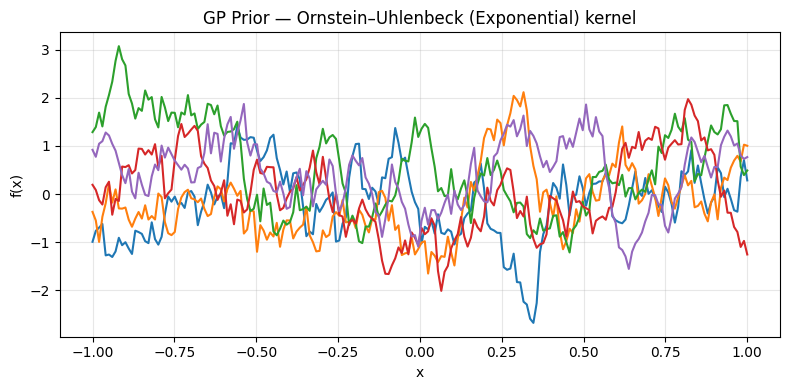

In [3]:
# Parameters
X_plot = np.linspace(-1.0, 1.0, 200)
ell = 0.2         # OU length-scale
var = 1.0
noise_std = 0.05

# 1) Prior samples (OU)
prior_samples = gp_prior_sample(X_plot, n_samples=5, kernel=ou_kernel, length_scale=ell, variance=var)
plt.figure(figsize=(8, 4))
for f in prior_samples:
    plt.plot(X_plot, f, lw=1.5)
plt.title("GP Prior — Ornstein–Uhlenbeck (Exponential) kernel")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



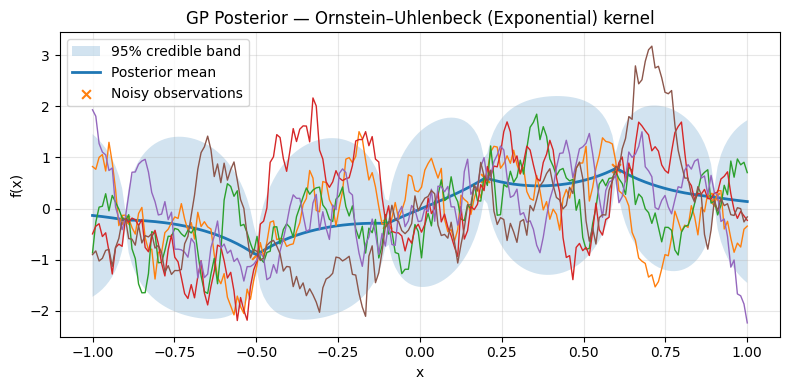

In [4]:
# 2) Posterior (OU)
def f_true(x):
    return np.sin(3*x) * np.exp(-x**2) + 0.1 * x

X_train = np.array([-0.9, -0.5, -0.1, 0.2, 0.6, 0.9])
y_train = f_true(X_train) + noise_std * rng.standard_normal(len(X_train))

mu, cov = gp_posterior(X_train, y_train, X_plot, noise=noise_std**2, kernel=ou_kernel, length_scale=ell, variance=var)
std = np.sqrt(np.clip(np.diag(cov), 0, None))

post_samples = rng.multivariate_normal(mean=mu, cov=cov + 1e-9*np.eye(len(X_plot)), size=5)

plt.figure(figsize=(8, 4))
plt.fill_between(X_plot, mu - 2*std, mu + 2*std, alpha=0.2, label="95% credible band")
plt.plot(X_plot, mu, lw=2, label="Posterior mean")
for f in post_samples:
    plt.plot(X_plot, f, lw=1)
plt.scatter(X_train, y_train, s=40, marker="x", label="Noisy observations")
plt.title("GP Posterior — Ornstein–Uhlenbeck (Exponential) kernel")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()